In [9]:
grammar_enbf = """
root  -> object

object -> "{" ws ( string ":" ws value ("," ws string ":" ws value)* )? "}"

value  -> object | array | string | number | ("true" | "false" | "null") ws

array  -> "[" ws ( value ("," ws value)* )? "]" ws

string -> "\"" [ \t!#-\[\]-~]* "\"" ws

number -> ("-"? ([0-9] | [1-9] [0-9]*)) ("." [0-9]+)? ([eE] [-+]? [0-9]+)? ws


ws ::= ([ \t\n] ws)?
"""

grammar_str = """
root  -> object
object -> "{" key ":" value "}"
key    -> "a" | "b"
value  ->  "1" | "2"
"""

In [2]:
from nltk import CFG
from nltk import ChartParser

In [58]:
grammar = CFG.fromstring("""
root -> 20 | 21
root -> 19 20 | 21
root -> 20 20

19 -> 18 16 18
20 -> 18 17 18
21 -> 18 18 18

16 -> 15 15 | 14
17 -> 15 16 | 14
18 -> 15 17 | 14

14 -> "a"
15 -> "b"


""")

parser = ChartParser(grammar)
sentence = 'b a b a b a'.split()
trees = []

for tree in parser.parse(sentence):
    print(tree)
    trees.append(tree)

(root
  (20
    (18 (15 b) (17 (14 a)))
    (17 (15 b) (16 (14 a)))
    (18 (15 b) (17 (14 a)))))
(root
  (21
    (18 (15 b) (17 (14 a)))
    (18 (15 b) (17 (14 a)))
    (18 (15 b) (17 (14 a)))))


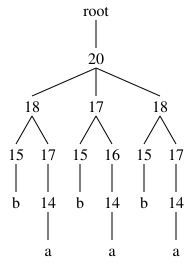

In [59]:
trees[0]

In [64]:
import ast

def string_to_tuple(s):
    return ast.literal_eval(s)

def convert_to_custom_format(sentence):
    levels = []
    terminals = []
    non_terminals = []

    def process_node(node, level=0):
        if isinstance(node, tuple):
            head = node[0]
            children = node[1:]

            if level == len(levels):
                levels.append([])
            levels[level].append(str(head))

            for child in children:
                if isinstance(child, tuple):
                    non_terminals.append(str(child[0]))
                    process_node(child, level + 1)
                else:
                    terminals.append(str(child))

    process_node(sentence)

    # Format the output
    levels_str = '; '.join([';'.join(level) for level in levels])
    non_terminals_str = ','.join(non_terminals)
    terminals_str = ','.join(terminals)

    return f"{levels_str};{non_terminals_str};{terminals_str}"

# Example usage
sentence_str = "('root', (20, (18, (15, 'b'), (17, (14, 'a'))), (17, (15, 'b'), (16, (14, 'a'))), (18, (15, 'b'), (17, (14, 'a')))))"
sentence_tuple = string_to_tuple(sentence_str)
formatted_output = convert_to_custom_format(sentence_tuple)

print(formatted_output)


root; 20; 18;17;18; 15;17;15;16;15;17; 14;14;14;20,18,15,17,14,17,15,16,14,18,15,17,14;b,a,b,a,b,a


In [1]:
import ast

def string_to_tuple(s):
    return ast.literal_eval(s)

def convert_to_format(sentence):
    levels = []

    def traverse(node, depth=0):
        if len(levels) <= depth:
            levels.append([])

        if isinstance(node, tuple):
            levels[depth].append(node[0])
            for child in node[1:]:
                traverse(child, depth + 1)
        else:
            levels[depth].append(node)

    traverse(sentence)

    # Convert levels to the desired format
    formatted_levels = ['\t'.join(','.join(map(str, level)) for level in levels)]
    return formatted_levels[0]

# Example usage
sentence_str = "('root', (20, (18, (15, 'b'), (17, (14, 'a'))), (17, (15, 'b'), (16, (14, 'a'))), (18, (15, 'b'), (17, (14, 'a')))))"
sentence_tuple = string_to_tuple(sentence_str)
formatted_output = convert_to_format(sentence_tuple)

print(formatted_output)


root	20	18,17,18	15,17,15,16,15,17	b,14,b,14,b,14	a,a,a


In [65]:
import ast
from nltk import CFG

def string_to_tuple(s):
    return ast.literal_eval(s)

def convert_to_grammar(sentence):
    rules = []

    def process_node(node):
        if isinstance(node, tuple):
            head = node[0]
            children = node[1:]
            child_symbols = []

            for child in children:
                if isinstance(child, tuple):
                    child_head = child[0]
                    child_symbols.append(str(child_head))
                    process_node(child)
                else:
                    child_symbols.append(str(child))

            rule = f"{head} -> {' '.join(child_symbols)}"
            rules.append(rule)

    process_node(sentence)
    return rules

def reward_function(sentence, grammar):
    rewards = []

    def check_node(node):
        if isinstance(node, tuple):
            head = node[0]
            children = node[1:]
            child_symbols = []

            for child in children:
                if isinstance(child, tuple):
                    child_head = child[0]
                    child_symbols.append(child_head)
                    check_node(child)
                else:
                    child_symbols.append(child)

            # Check if the production is valid
            production = f"{head} -> {' '.join(map(str, child_symbols))}"
            if production in grammar:
                rewards.append(1)  # Reward for valid production
            else:
                rewards.append(0)  # No reward for invalid production

    check_node(sentence)
    return rewards

# Define the grammar
grammar_rules = [
    "root -> 20",
    "root -> 19 20",
    "root -> 20 20",
    "19 -> 18 16 18",
    "20 -> 18 17 18",
    "21 -> 18 18 18",
    "16 -> 15 15",
    "16 -> 14",
    "17 -> 15 16",
    "17 -> 14",
    "18 -> 15 17",
    "18 -> 14",
    "14 -> 'a'",
    "15 -> 'b'"
]

# Example usage
sentence_str = "(20, (18, (15, 'b'), (17, (14, 'a'))), (17, (15, 'b'), (16, (14, 'a'))), (18, (15, 'b'), (17, (14, 'a'))))"
sentence_tuple = string_to_tuple(sentence_str)
rules = convert_to_grammar(sentence_tuple)

# Evaluate rewards
rewards = reward_function(sentence_tuple, grammar_rules)

# Output the rules and rewards
print("Generated Rules:")
for rule in rules:
    print(rule)

print("\nRewards:")
print(rewards)


Generated Rules:
15 -> b
14 -> a
17 -> 14
18 -> 15 17
15 -> b
14 -> a
16 -> 14
17 -> 15 16
15 -> b
14 -> a
17 -> 14
18 -> 15 17
20 -> 18 17 18

Rewards:
[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1]


In [48]:
import random
def generate_sentence(grammar, start_symbol=None):
    if start_symbol is None:
        start_symbol = grammar.start()
    
    productions = grammar.productions(lhs=start_symbol)
    production = random.choice(productions)
    
    result = []
    for symbol in production.rhs():
        if isinstance(symbol, str):  # Terminal
            result.append(symbol)
        else:  # Non-terminal
            result.extend(generate_sentence(grammar, symbol))
    
    return result

# Generate and print sentences
for _ in range(100):
    sentence = generate_sentence(grammar)
    print(' '.join(sentence))

b a b a b b a
a b a a
a b b b b b b b b a b b b a
a b b a a b a b b a
b a b b b b a a a b b a
b a a a
a a a a b a b a
a a a a b a a
a b a a
b b b b a b b b b b a a a
a a b b a
b a a a a b b b b b b b
b a b b a b b b b
a b a a a b a b a
b b a a a
b b a a b b b b
a a a
a b a b a
b a a b a a b b b a
b b b b b b a b b a a a
b a a a b a b a a
b a b b b a
a a b a
b a a a
a a a
b b a a a a b a a
a b b b a b b b b b a b a
a a a
b b a a a a b b b b a
b a b a a
a b a a
a b b b a
a b a a
b b a b b b a b a a a
b a b b b b a a a b a
b a a a
b b b b a b a
b b a a b b a
a b a a a a b b b b
a a a
b a b b a b a
b b b b a b b b b
b b b b a a b a a b a
a a b b b b b a a b b a
b a a b b a
a a a
b b a b a b a
a b a a
a b a b b a
b a a a b b b b a b a
a b b b a a b b b a
a b b a b a
b b b b b b a a
a b b b b b b b b a b a a
b b a a a b b b b b a b b b b
a b a a
b a b b a b b b b
a a b a
b a a b b a b a a a
a b b a b a a b a
b b a b b b a a a b a
a b b b b b a
b a b b b a a b a a
b a a b b a a a a
a b a b a
